# Análisis exploratorio del dataset para aplicar ML
**Propósito**: Hacer pequeñas comprobaciones analíticas de los datos.

In [1]:
import sys
import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '/tfm/python_notebooks')
from tfm_lib import utils as tfm_utils

In [2]:
#Inicializar sesión de Spark
spark = tfm_utils.get_spark_session(app_name="ML_create_dataset")

#Cargamos los datos
df_data=tfm_utils.read_from_delta(spark, "ml.idealista_crem.dataset_to_apply_ml")

num_col_orig=len(df_data.columns)

In [3]:
#agrupamos las columnas con la información de transacciones inmobiliarias de trimestres a años enteros
for year in range(2004,2024+1):
    columns_of_year=[c for c in df_data.columns if c.lower().endswith(f"_trimestre_{year}_transacciones_inmobiliarias")]
    sum_exp=" + ".join(columns_of_year)

    df_data=df_data.withColumn(f"{year}_transacciones_inmobiliarias", F.expr(sum_exp))

#Drop columns
columns_to_drop=[c for c in df_data.columns if "_trimestre_" in c]

df_data=df_data.drop(*columns_to_drop)
num_cols=len(df_data.columns)

print(f"Con estas agrupaciones pasamos de {num_col_orig} a {num_cols}")
num_col_orig=num_cols

Con estas agrupaciones pasamos de 253 a 186


## Limpieza de campos del CREM, quitamos los años de cada medida que sean redundantes
Creamos una función con la cual, dado un dataframe de **Pandas** nos devuelve la lista de las columnas con correlación (en valor absoluto) por encima de un umbral y las que están por debajo, de esta forma podremos quitar campos que guardan información redundante o muy parecida.

In [4]:
#Cambiamos la verion original para que, cuando comparemos dos variables, para saber cual vamos a borrar 
#eligamos la más correlacionada con la variable a predecir
def correlation_threshold(df, threshold=0.9, target="price"):
    #Calcula la matriz de correlación absoluta (excluyendo la target si se proporciona)
    features = [col for col in df.columns if col != target]
    corr_matrix = df[features].corr().abs()
    
    #Genera una máscara para la matriz triangular superior (excluye la diagonal)
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    #Conjunto para almacenar las columnas a eliminar
    to_drop = set()
    
    #Calculamos correlación de cada feature con el target
    corr_with_target = df.corr()[target].abs().drop(target)
    
    #Recorremos las columnas de la matriz triangular superior
    for column in upper_tri.columns:
        # Buscamos pares con correlación > threshold
        high_corr_pairs = upper_tri.index[upper_tri[column] > threshold]
        
        for high_corr_col in high_corr_pairs:
            # Si ya se decidió eliminar alguna de las dos, saltamos
            if column in to_drop or high_corr_col in to_drop:
                continue
            
            # Decidir cuál eliminar basado en la correlación con la target
            if target is not None:
                # Eliminamos la que tenga menor correlación con la target
                if corr_with_target[column] < corr_with_target[high_corr_col]:
                    to_drop.add(column)
                else:
                    to_drop.add(high_corr_col)
            else:
                # Si no hay target, comportamiento original: eliminar la segunda (o primera)
                to_drop.add(high_corr_col)
    
    # Columnas que sobreviven: todas las features excepto las marcadas para eliminar
    if target is not None:
        all_features = set(features)
    else:
        all_features = set(df.columns)
    
    survivals = list(all_features - to_drop)
    
    # Retornamos las dos listas
    return survivals, list(to_drop)

In [5]:
fields=['distribucion_de_la_renta_p80_p20', 'edad_media_poblacion', 'indice_de_gini', 'porcentaje_de_hogares_unipersonales', 
        'porcentaje_de_poblacion_de_65_o_mas', 'porcentaje_de_poblacion_de_menos_de_18', 'porcentaje_poblacion_espanola', 
        'renta_bruta_media_por_persona', 'renta_neta_media_por_persona', 'tamano_medio_del_hogar', 'tamano_poblacion', 
        'transacciones_inmobiliarias']

columns_to_save={}
columns_to_drop=[]

for field in fields:
    #Recuperamos todas las columnas de una medida para los diferentes años
    columns_field=[c for c in df_data.columns if field in c]

    #recuperamos esas columnas y la objetivo y la pasamos a Pandas
    df_field=df_data.select(*columns_field, "price").toPandas()
    
    #Recuperamos que columnas a conservar y a eliminar
    survivals, to_drop=correlation_threshold(df_field)

    columns_to_save[field]=survivals
    columns_to_drop+=to_drop

    print(field+": "+str(survivals))

#Efectuamos el borrado de campos
df_data=df_data.drop(*columns_to_drop)

#pintamos la comparativo
num_cols=len(df_data.columns)
print(f"Con esta limpieza pasamos de {num_col_orig} a {len(df_data.columns)} con esta limpieza de campos.")
num_col_orig=num_cols

distribucion_de_la_renta_p80_p20: ['2016_distribucion_de_la_renta_p80_p20', '2017_distribucion_de_la_renta_p80_p20', '2021_distribucion_de_la_renta_p80_p20', '2023_distribucion_de_la_renta_p80_p20']
edad_media_poblacion: ['2016_edad_media_poblacion']
indice_de_gini: ['2023_indice_de_gini']
porcentaje_de_hogares_unipersonales: ['2016_porcentaje_de_hogares_unipersonales']
porcentaje_de_poblacion_de_65_o_mas: ['2016_porcentaje_de_poblacion_de_65_o_mas']
porcentaje_de_poblacion_de_menos_de_18: ['2017_porcentaje_de_poblacion_de_menos_de_18']
porcentaje_poblacion_espanola: ['2019_porcentaje_poblacion_espanola']
renta_bruta_media_por_persona: ['2015_renta_bruta_media_por_persona']
renta_neta_media_por_persona: ['2018_renta_neta_media_por_persona']
tamano_medio_del_hogar: ['2015_tamano_medio_del_hogar']
tamano_poblacion: ['2023_tamano_poblacion']
transacciones_inmobiliarias: ['2006_transacciones_inmobiliarias', '2007_transacciones_inmobiliarias', '2017_transacciones_inmobiliarias', '2024_trans

## Segunda limpieza de campos para quitar información redundante en todo el dataset.
Aplicamos la misma limpieza de antes a todas las columnas.

In [6]:
df_full=df_data.toPandas()

survivals, to_drop=correlation_threshold(df_full)

#Aplicamos el borrado de columnas
df_data=df_data.drop(*to_drop)

print(f"{len(survivals)} COLUMNAS QUE MANTENEMOS")
print(survivals)

print(50*"-")

print(f"{len(to_drop)} COLUMNAS QUE BORRAMOS")
print(to_drop)

79 COLUMNAS QUE MANTENEMOS
['municipio_villanueva_del_rio_segura', 'tiene_ascensor', 'es_vendedor_particular', 'municipio_caravaca_de_la_cruz', 'tiene_calefaccion', 'es_bajo', 'tiene_trastero', 'municipio_aledo', '2017_transacciones_inmobiliarias', 'municipio_santomera', 'municipio_ceuti', 'municipio_alcantarilla', 'metros_cuadrados_construidos', 'numero_plantas', 'municipio_fuente_alamo', 'municipio_jumilla', 'municipio_cehegin', '2023_tamano_poblacion', '2019_porcentaje_poblacion_espanola', 'municipio_beniel', '2017_distribucion_de_la_renta_p80_p20', '2015_renta_bruta_media_por_persona', '2006_transacciones_inmobiliarias', 'municipio_pliego', 'tiene_piscina', 'municipio_abaran', 'estado_ocupacion_vacio', 'municipio_san_javier', 'municipio_puerto_lumbreras', 'municipio_totana', 'habitaciones', '2024_transacciones_inmobiliarias', 'municipio_cieza', 'municipio_aguilas', 'municipio_los_alcazares', 'municipio_fortuna', 'municipio_mula', 'es_piso', 'municipio_mazarron', 'tiene_balcon', 'ti

## Limpieza de variables por baja correlación con la variable objetivo

Lo que haremos ahora será una nueva reducción de dimensionalidad. En este caso, de las variables que han pasado las dos limpiezas anteriores, quitaremos aquellas variables que tienen poca correlación absoluta con respecto a la variable objetivo, tomamos un umbral de correlación de $|\rho| < 0.1$. Esto lo hacemos de nuevo para reducir la complejidad del dataset y, además, para evitar el overfitting en el entrenamiento de modelos.

In [7]:
#Definimos una función para devolver la lista de columnas poco correlacionada dado un umbral
def obtener_columnas_poco_correlacionadas(threshold, correlation_matrix):
    corr_matrix=correlation_matrix.copy()
    
    variables_poco_correlacionadas = corr_matrix[corr_matrix < threshold].index
    variables_poco_correlacionadas.columns = ['Variable_1', 'Correlacion']
    variables_poco_correlacionadas=variables_poco_correlacionadas.sort_values().tolist()
    
    return variables_poco_correlacionadas


#Pasamos a un dataframe de Pandas
df_data_pd=df_data.toPandas()
y = df_data_pd['price'].values
y_series = pd.Series(y, name='price_orig')

correlation_matrix = np.abs(df_data_pd.corrwith(y_series))
correlation_matrix = correlation_matrix.drop('price')

threshold=0.1
cols_poco_corr=obtener_columnas_poco_correlacionadas(threshold, correlation_matrix)

print("Variables con correlación absoluta menor que {}".format(threshold))
print(cols_poco_corr)
print(f"Un total de {len(cols_poco_corr)} columnas.")

#Hacemos el borrado de las variables poco correlacionadas
df_data=df_data.drop(*cols_poco_corr)

Variables con correlación absoluta menor que 0.1
['2006_transacciones_inmobiliarias', '2007_transacciones_inmobiliarias', '2015_tamano_medio_del_hogar', '2016_porcentaje_de_hogares_unipersonales', '2016_porcentaje_de_poblacion_de_65_o_mas', '2017_porcentaje_de_poblacion_de_menos_de_18', '2019_porcentaje_poblacion_espanola', '2024_transacciones_inmobiliarias', 'es_atico', 'es_bajo', 'es_vendedor_particular', 'estado_ocupacion_arrendado', 'metros_cuadrados_construidos', 'municipio_abanilla', 'municipio_abaran', 'municipio_aguilas', 'municipio_albudeite', 'municipio_alcantarilla', 'municipio_aledo', 'municipio_alguazas', 'municipio_alhama_de_murcia', 'municipio_archena', 'municipio_beniel', 'municipio_blanca', 'municipio_bullas', 'municipio_calasparra', 'municipio_campos_del_rio', 'municipio_caravaca_de_la_cruz', 'municipio_cartagena', 'municipio_cehegin', 'municipio_ceuti', 'municipio_cieza', 'municipio_fortuna', 'municipio_fuente_alamo', 'municipio_jumilla', 'municipio_la_union', 'munic

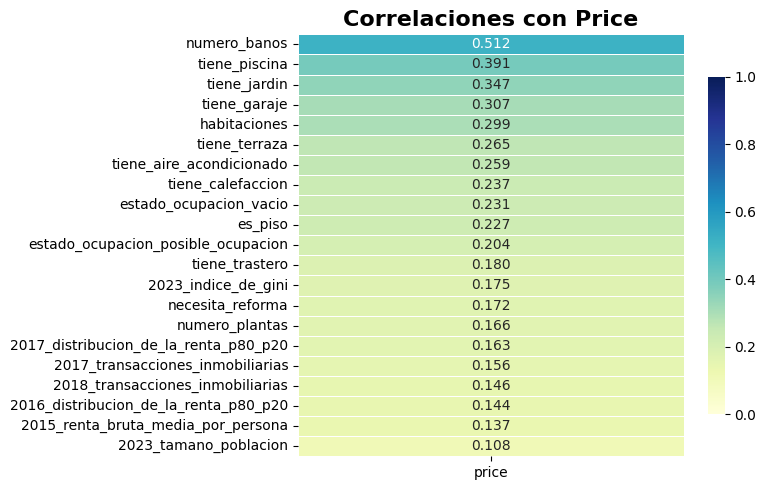

In [8]:
df_data_pd=df_data.toPandas()

#Recuperamos la matriz de correlaciones
corr = np.abs(df_data_pd.drop(['price'], axis=1).corr())

#Seleccionar solo las correlaciones con price
corr_with_price = np.abs(df_data_pd.corr())[['price']].sort_values(by='price', ascending=False)

#Eliminar la correlación de price_orig consigo misma (que es 1.0)
corr_with_price = corr_with_price[corr_with_price['price'] < 1.0]

#Crear un DataFrame para el heatmap (necesitamos formato 2D)
#Opción 1: Mostrar como barra horizontal
fig, ax = plt.subplots(figsize=(8, 5))

# Crear un heatmap de una sola columna
sns.heatmap(corr_with_price, annot=True, fmt='.3f', cmap='YlGnBu', 
            linewidths=0.5, cbar_kws={'shrink': 0.8}, 
            vmin=0, vmax=1)

plt.title('Correlaciones con Price', fontsize=16, fontweight='bold')
#plt.ylabel('Variables', fontsize=10)
#plt.xlabel('Price', fontsize=10)
plt.tight_layout()
plt.show()

# Normalizado
Lo que haremos ahora será estandarizar los campos, a cada campo numérico lo que haremos será normalizarlo, es decir, restarle su media y dividir el resultado por su desviación estándar.

In [9]:
#Aplicamos solo donde tiene sentido, en los campos doubles, no en los enteros
df_data.createOrReplaceTempView(f"df_data")

double_cols=[field.name for field in df_data.schema.fields if isinstance(field.dataType, DoubleType)]

for col in double_cols:
    #definimos los dataframes de coeficientes máximos y mínimos
    df_coef=spark.sql(f"SELECT '{col}' as _col, AVG({col}) as _mean, STDDEV({col}) as _std_desv FROM df_data")
    df_coef.createOrReplaceTempView(f"df_coef_{col}")

    #conservamos la variable objetivo original
    if col.lower()=="price":
        continue

    #Normalizamos
    mean=df_data.select(F.mean(col)).first()[0]
    stddev=df_data.select(F.stddev(col)).first()[0]
    
    df_data=df_data.withColumn(col, (F.col(col)-mean)/stddev)

#Recuperamos el dataframe de coeficientes
alias_list=["select * from df_coef_"+col for col in double_cols]
union_expr=" union all ".join(alias_list)

df_coef=spark.sql(union_expr)

In [10]:
# Mostrar los datos estructurados
tfm_utils.display(df_data.select(*double_cols))

,2015_renta_bruta_media_por_persona,2016_distribucion_de_la_renta_p80_p20,2017_distribucion_de_la_renta_p80_p20,2023_indice_de_gini,2023_tamano_poblacion,habitaciones,numero_banos,price,2017_transacciones_inmobiliarias,2018_transacciones_inmobiliarias
0,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,1.762765,0.131091,89900.0,-1.135515,-1.057131
1,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,-0.110518,0.131091,175000.0,-1.135515,-1.057131
2,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,-0.110518,-1.179691,149900.0,-1.135515,-1.057131
3,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,-1.047160,0.131091,135000.0,-1.135515,-1.057131
4,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,0.826124,0.131091,210000.0,-1.135515,-1.057131
5,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,1.762765,1.441872,255500.0,-1.135515,-1.057131
6,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,0.826124,1.441872,289900.0,-1.135515,-1.057131
7,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,-0.110518,0.131091,245500.0,-1.135515,-1.057131
8,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,-0.110518,0.131091,276100.0,-1.135515,-1.057131
9,-0.271374,-1.035674,-1.12154,-1.709125,-0.807008,0.826124,1.441872,420000.0,-1.135515,-1.057131


## Guardamos datos

In [11]:
#Guaramos coeficientes
ml_table_name = "ml.idealista_crem.dataset_for_analysis_coeff"
delta_path = tfm_utils.full_table_path(ml_table_name)

(df_coef
    .write
    .mode("overwrite")
    .option("overwriteSchema","true")
    .format("delta")
    .save(delta_path)
)

# Normalizamos el dataframe del dataset
df_normalized = tfm_utils.normalize_df(df_data)
#Guardamos
ml_table_name = "ml.idealista_crem.dataset_for_analysis"
delta_path = tfm_utils.full_table_path(ml_table_name)

(df_normalized
    .write
    .mode("overwrite")
    .option("overwriteSchema","true")
    .format("delta")
    .save(delta_path)
)

print(f"¡Escritura en la tabla {delta_path} completada con exito!")

¡Escritura en la tabla /tfm/delta_lake/ml/idealista_crem/dataset_for_analysis completada con exito!
